<a href="https://colab.research.google.com/github/dishanth2k6/Company-Projects/blob/main/Credit_Card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import io

# Open the upload widget for the fraud dataset
uploaded = files.upload()

# Get the filename dynamically
file_name = list(uploaded.keys())[0]
print(f"\nSuccessfully uploaded: {file_name}")

Saving creditcard.csv to creditcard.csv

Successfully uploaded: creditcard.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

print("Imbalanced-learning and classification libraries loaded successfully!")

Imbalanced-learning and classification libraries loaded successfully!


Transaction counts by class:
Class
0    284315
1       492
Name: count, dtype: int64
Normal Transactions: 99.83%
Fraudulent Transactions: 0.17%


/tmp/ipykernel_2811/806878326.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set1')


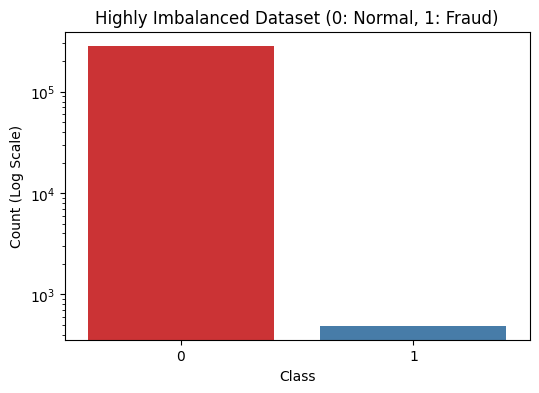

In [3]:
# Load dataset
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Check distribution of the 'Class' column (0 = Normal, 1 = Fraud)
print("Transaction counts by class:")
print(df['Class'].value_counts())

# Calculate percentages
normal_pct = (df['Class'].value_counts()[0] / len(df)) * 100
fraud_pct = (df['Class'].value_counts()[1] / len(df)) * 100
print(f"Normal Transactions: {normal_pct:.2f}%")
print(f"Fraudulent Transactions: {fraud_pct:.2f}%")

# Visualize the massive imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='Set1')
plt.title('Highly Imbalanced Dataset (0: Normal, 1: Fraud)')
plt.yscale('log') # Log scale because normal completely eclipses fraud
plt.ylabel('Count (Log Scale)')
plt.show()

In [4]:
# Features and Target
X = df.drop(columns=['Class'])
y = df['Class']

# Scale the unscaled 'Amount' and 'Time' columns
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# Train-Test Split (80-20, stratify ensures test set preserves the fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split and scaled safely before resampling!")

Data split and scaled safely before resampling!


In [5]:
print("Before SMOTE, training fraud count:", sum(y_train == 1))

# Initialize SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE, balanced training data shape:", X_train_res.shape)
print("After SMOTE, training fraud count:", sum(y_train_res == 1))

Before SMOTE, training fraud count: 394
After SMOTE, balanced training data shape: (454902, 30)
After SMOTE, training fraud count: 227451


In [6]:
# Initialize models
lr_fraud = LogisticRegression(max_iter=1000)
xgb_fraud = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1)

# Fit models on the SMOTE-resampled training data
print("Training Logistic Regression on balanced data...")
lr_fraud.fit(X_train_res, y_train_res)

print("Training XGBoost on balanced data (This might take a minute)...")
xgb_fraud.fit(X_train_res, y_train_res)

print("Models successfully trained on resampled distributions!")

Training Logistic Regression on balanced data...
Training XGBoost on balanced data (This might take a minute)...
Models successfully trained on resampled distributions!



================ Logistic Regression REPORT ================
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



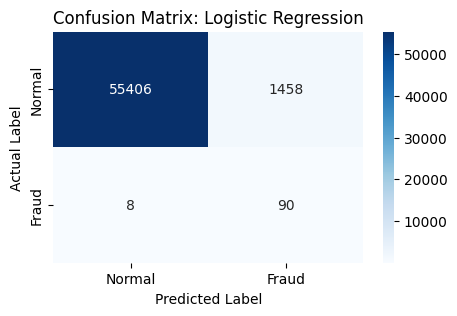


================ XGBoost REPORT ================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.42      0.87      0.57        98

    accuracy                           1.00     56962
   macro avg       0.71      0.93      0.78     56962
weighted avg       1.00      1.00      1.00     56962



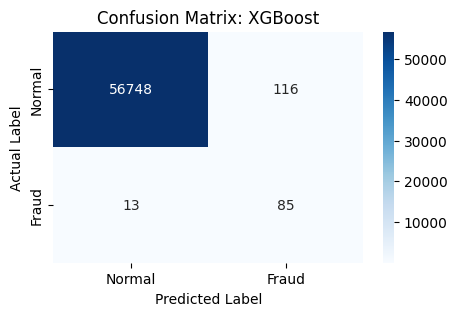

In [7]:
models = {'Logistic Regression': lr_fraud, 'XGBoost': xgb_fraud}

for name, model in models.items():
    preds = model.predict(X_test)
    print(f"\n================ {name} REPORT ================")
    print(classification_report(y_test, preds))

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, preds)

    # Plot heatmap of confusion matrix
    plt.figure(figsize=(5, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()